## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 07 · Spatial cross-validation of the calibration

The LSOA fit of notebook 06 is *in-sample*: the same LSOAs were used to fit the seven physics parameters.
"How well does the calibrated model transfer to areas it was not fitted on" is answered with
**leave-one-band-out** over the spatial bands of `data/inputs/benchmarks/spatial_cv_folds_lsoa.csv`
(contiguous groups of LSOAs, so that no building sits on both sides of a split):

* for each band *k*, the physics parameters are re-fitted on the other six bands
  (Py-BOBYQA warm-started from the full-population optimum, `MAXFUN_CV` evaluations of the
  archetype tier), then the held-out band is scored with WAPE, NMBE and predictive R²;
* the seven out-of-fold predictions are pooled into one out-of-sample LSOA table used by the
  atlas of notebook 09.

The band-wise result is the honest transfer test. (The next DESNZ release is reserved for a one-time
temporal evaluation.)

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import config as CFG
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
from ukubem.calibrate import (ArchetypeCalibrator, PHYS_BOUNDS, POST_FIXED, make_representatives, _stock_delivered, evaluate_on)
from ukubem import metrics as M, maps, profiles, measures, stock
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


In [2]:
theta = json.load(open(UBEM_OUT / "06_calibrated_theta.json")); phys, post = theta["physics"], theta["post"]
inputs0 = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
labels = pd.read_parquet(TABLE_LABELS)
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
inputs, reps = make_representatives(inputs0)
folds = pd.read_csv(CV_FOLDS)
A_cal = UKGeometryAssumptions().with_(wall_u_scale=phys["wall_u_scale"], roof_u_scale=phys["roof_u_scale"], window_u_scale=phys["window_u_scale"],
                                      infil_scale=phys["infil_scale"], gains_scale=phys["gains_scale"], setpoint_offset_c=phys["setpoint_offset_c"],
                                      stochastic_setback_c=phys.get("setback_c", 12.0))
inten_cal = pd.read_csv(UBEM_OUT / "06_archetype_intensities_calibrated.csv", index_col=0)
stock_cal = pd.read_parquet(UBEM_OUT / "06_stock_calibrated.parquet")
print(f"{len(inputs):,} dwellings, {len(reps)} representatives, {folds['fold'].nunique()} spatial folds; calibrated physics {phys}")

57,300 dwellings, 102 representatives, 7 spatial folds; calibrated physics {'wall_u_scale': 1.0652602409167062, 'roof_u_scale': 1.1248578219743166, 'window_u_scale': 1.25, 'infil_scale': 0.8129959823081263, 'gains_scale': 0.8155295436843902, 'setpoint_offset_c': 1.0, 'setback_c': 15.691329877128062}


In [3]:
MAXFUN_CV = 8            # archetype-tier evaluations per fold
N_REAL = 3               # the calibration's stratified household design
sim_cache = {}           # the representatives' simulation does not depend on the fold (only the objective's LSOAs do): folds share it
results, oof = [], []
x0 = {k: float(phys[k]) for k in PHYS_BOUNDS}
for k in sorted(folds["fold"].unique()):
    test = folds.loc[folds["fold"] == k, "LSOA"].tolist(); train = folds.loc[folds["fold"] != k, "LSOA"].tolist()
    hist = UBEM_OUT / f"07_cv_history_fold{k}.csv"
    cal = ArchetypeCalibrator(inputs=inputs, labels=labels, bench_lsoa=bench_lsoa, reps=reps, epw=str(EPW), pybui_src=str(PBE_SRC),
                              n_real=N_REAL, seed=SEED, n_jobs=N_JOBS, history_path=hist, lsoas=train, sim_cache=sim_cache)
    t0 = time.time()
    if hist.exists() and len(pd.read_csv(hist)) >= MAXFUN_CV:
        cal.history = pd.read_csv(hist).to_dict("records")
    else:
        cal.run(maxfun=MAXFUN_CV, rhobeg=0.08, x0=x0)
    h = pd.DataFrame(cal.history); best = h.loc[h["J"].idxmin()] if "J" in h else h.loc[h["objective"].idxmin()]
    phys_k = {p: float(best[p]) for p in PHYS_BOUNDS}
    inten_k = cal.simulate(phys_k)
    m_train = evaluate_on(inputs, inten_k, labels, bench_lsoa, post, lsoas=train)
    m_test = evaluate_on(inputs, inten_k, labels, bench_lsoa, post, lsoas=test)
    st_k = _stock_delivered(inputs, inten_k, post); t_k = aggregate_lsoa(st_k, labels, bench_lsoa)
    oof.append(t_k.loc[t_k.index.isin(test)].assign(fold=k))
    results.append({"fold": k, "n_train": len(train), "n_test": len(test), "minutes": (time.time() - t0) / 60,
                    **{f"train_{c}": m_train[c] for c in ("J", "gas_WAPE_pct", "gas_NMBE_pct", "elec_WAPE_pct", "elec_NMBE_pct")},
                    **{f"test_{c}": m_test[c] for c in ("J", "gas_WAPE_pct", "gas_NMBE_pct", "gas_R2_predictive", "elec_WAPE_pct", "elec_NMBE_pct", "elec_R2_predictive")},
                    **{f"phys_{p}": v for p, v in phys_k.items()}})
    print(f"fold {k}: train gas WAPE {m_train['gas_WAPE_pct']:.1f}%  ->  held-out gas WAPE {m_test['gas_WAPE_pct']:.1f}% NMBE {m_test['gas_NMBE_pct']:+.1f}%  "
          f"elec WAPE {m_test['elec_WAPE_pct']:.1f}%   [{(time.time()-t0)/60:.0f} min]", flush=True)
cv = pd.DataFrame(results).set_index("fold"); cv.to_csv(UBEM_OUT / "07_cv_by_fold.csv")
oof = pd.concat(oof); oof.to_csv(UBEM_OUT / "07_cv_lsoa_predictions.csv")
cv.round(2)

fold 0: train gas WAPE 6.2%  ->  held-out gas WAPE 8.7% NMBE -4.3%  elec WAPE 8.2%   [6 min]


fold 1: train gas WAPE 6.4%  ->  held-out gas WAPE 9.0% NMBE -6.0%  elec WAPE 8.2%   [6 min]


fold 2: train gas WAPE 6.6%  ->  held-out gas WAPE 5.8% NMBE +3.7%  elec WAPE 8.5%   [6 min]


fold 3: train gas WAPE 6.5%  ->  held-out gas WAPE 6.8% NMBE +2.6%  elec WAPE 12.7%   [0 min]


fold 4: train gas WAPE 6.9%  ->  held-out gas WAPE 4.3% NMBE +1.4%  elec WAPE 12.6%   [0 min]


fold 5: train gas WAPE 6.8%  ->  held-out gas WAPE 5.3% NMBE -3.2%  elec WAPE 11.0%   [0 min]


fold 6: train gas WAPE 6.6%  ->  held-out gas WAPE 7.7% NMBE -7.1%  elec WAPE 13.8%   [0 min]


,n_train,n_test,minutes,train_J,train_gas_WAPE_pct,train_gas_NMBE_pct,train_elec_WAPE_pct,train_elec_NMBE_pct,test_J,test_gas_WAPE_pct,test_gas_NMBE_pct,test_gas_R2_predictive,test_elec_WAPE_pct,test_elec_NMBE_pct,test_elec_R2_predictive,phys_wall_u_scale,phys_roof_u_scale,phys_window_u_scale,phys_infil_scale,phys_gains_scale,phys_setpoint_offset_c,phys_setback_c
fold,,,,,,,,,,,,,,,,,,,,,,
0,72,12,5.94,0.03,6.23,-1.74,11.30,1.76,0.02,8.67,-4.27,0.91,8.25,2.44,0.75,1.07,1.12,1.25,0.81,0.82,1.0,15.69
1,72,12,5.77,0.02,6.40,-2.59,11.29,2.62,0.03,8.96,-5.99,0.78,8.18,-3.96,0.82,1.07,1.12,1.25,0.81,0.86,1.0,15.69
2,72,12,5.61,0.03,6.63,-1.98,11.24,1.35,0.01,5.75,3.69,0.78,8.50,6.53,0.27,1.07,1.17,1.25,0.81,0.82,1.0,15.69
3,71,13,0.01,0.02,6.48,-1.93,10.64,0.18,0.03,6.77,2.61,0.83,12.69,12.24,-0.86,1.07,1.17,1.25,0.81,0.82,1.0,15.69
4,73,11,0.01,0.02,6.93,-1.77,10.63,0.60,0.03,4.29,1.40,0.94,12.58,9.23,0.53,1.07,1.17,1.25,0.81,0.82,1.0,15.69
5,72,12,0.01,0.02,6.76,-1.86,10.90,1.45,0.03,5.34,-3.18,0.84,11.04,4.26,0.59,1.07,1.12,1.25,0.81,0.82,1.0,15.69
6,72,12,0.01,0.02,6.55,-2.20,10.20,5.02,0.03,7.68,-7.14,0.79,13.83,-13.65,0.30,1.07,1.12,1.25,0.81,0.86,1.0,15.69


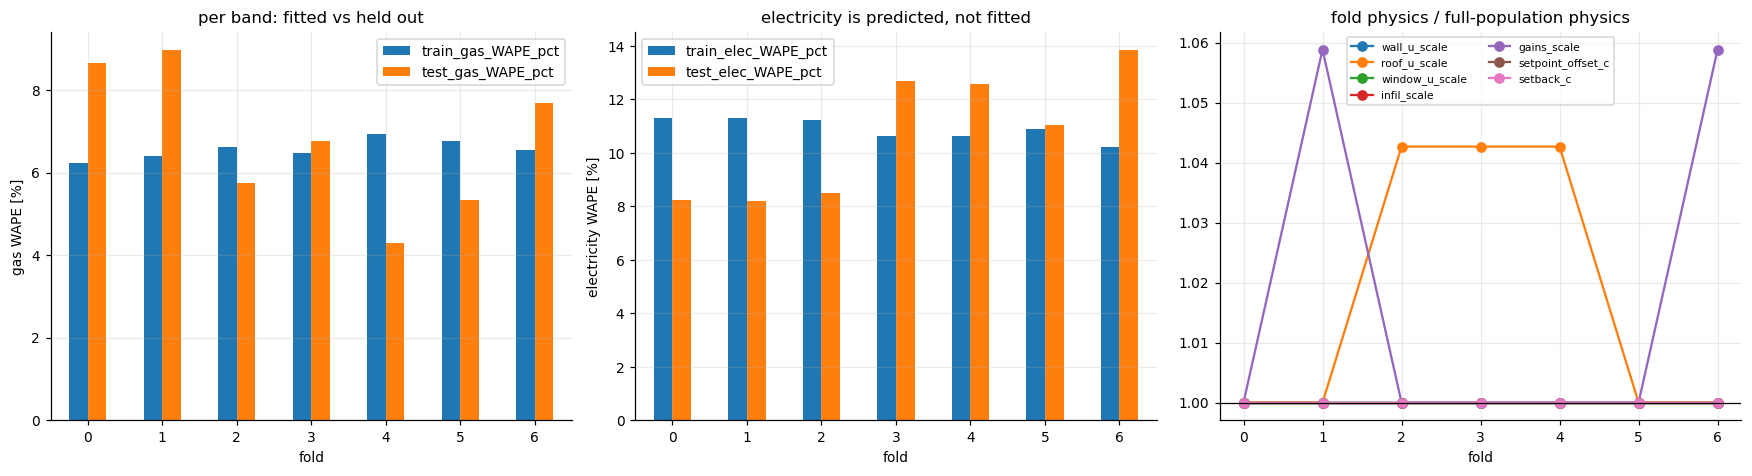

,in-sample (nb06),out-of-fold (7 bands)
gas_WAPE_pct,6.54,6.73
gas_NMBE_pct,-2.06,-2.01
gas_R2_predictive,0.91,0.91
elec_WAPE_pct,10.92,10.98
elec_NMBE_pct,1.85,1.85
elec_R2_predictive,0.72,0.71


In [4]:
# pooled out-of-fold metrics on LSOA totals (mean x meters)
g = oof.dropna(subset=["sim_gas_mean_kWh", "gas_mean_kWh"]); e = oof.dropna(subset=["sim_elec_mean_kWh", "elec_mean_kWh"])
pooled = {"gas_WAPE_pct": M.wape_pct(g["gas_mean_kWh"] * g["gas_meters"], g["sim_gas_mean_kWh"] * g["gas_meters"]),
          "gas_NMBE_pct": M.nmbe_pct(g["gas_mean_kWh"] * g["gas_meters"], g["sim_gas_mean_kWh"] * g["gas_meters"]),
          "gas_R2_predictive": M.predictive_r2(g["gas_mean_kWh"], g["sim_gas_mean_kWh"]),
          "elec_WAPE_pct": M.wape_pct(e["elec_mean_kWh"] * e["elec_meters"], e["sim_elec_mean_kWh"] * e["elec_meters"]),
          "elec_NMBE_pct": M.nmbe_pct(e["elec_mean_kWh"] * e["elec_meters"], e["sim_elec_mean_kWh"] * e["elec_meters"]),
          "elec_R2_predictive": M.predictive_r2(e["elec_mean_kWh"], e["sim_elec_mean_kWh"])}
insample = mape(aggregate_lsoa(stock_cal, labels, bench_lsoa))
comp = pd.DataFrame({"in-sample (nb06)": {k: insample[k] for k in pooled}, "out-of-fold (7 bands)": pooled})
json.dump({"pooled_out_of_fold": pooled, "in_sample": {k: insample[k] for k in pooled}}, open(UBEM_OUT / "07_cv_summary.json", "w"), indent=2)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
cv[["train_gas_WAPE_pct", "test_gas_WAPE_pct"]].plot.bar(ax=axes[0], rot=0); axes[0].set_ylabel("gas WAPE [%]"); axes[0].set_title("per band: fitted vs held out")
cv[["train_elec_WAPE_pct", "test_elec_WAPE_pct"]].plot.bar(ax=axes[1], rot=0); axes[1].set_ylabel("electricity WAPE [%]"); axes[1].set_title("electricity is predicted, not fitted")
pc = [c for c in cv.columns if c.startswith("phys_")]
(cv[pc].rename(columns=lambda c: c[5:]) / pd.Series(phys)).plot(ax=axes[2], marker="o"); axes[2].axhline(1, color="k", lw=0.8); axes[2].set_title("fold physics / full-population physics"); axes[2].legend(fontsize=7, ncol=2)
plt.tight_layout(); fig.savefig(FIG_UBEM / "07_spatial_cv.png", bbox_inches="tight"); plt.show()
comp.round(2)

**Reading it.** The held-out WAPE tells the council how much to trust the model in an area it
was never fitted on; the spread of the fold-wise physics says how stable the calibrated
parameters are (one identifiable direction with the setpoint on its bound: the equifinality of setpoint
and losses). Electricity is not fitted anywhere in this tool (BREDEM usage
model + simulated heat-pump / electric heating), so its WAPE is a genuine prediction test.